<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/Deep%20Learning/Pytorch/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [6]:
torch.manual_seed(42)

In [7]:
df = pd.read_csv('fashion-mnist_test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103.0,87.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,0,0,0,0,0,0,0,...,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0,0,0,0,0,0,14,53,99,...,0.0,0.0,0.0,0.0,63.0,53.0,31.0,0.0,0.0,0.0
3,2,0,0,0,0,0,0,0,0,0,...,137.0,126.0,140.0,0.0,133.0,224.0,222.0,56.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103.0,87.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,0,0,0,0,0,0,0,...,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0,0,0,0,0,0,14,53,99,...,0.0,0.0,0.0,0.0,63.0,53.0,31.0,0.0,0.0,0.0
3,2,0,0,0,0,0,0,0,0,0,...,137.0,126.0,140.0,0.0,133.0,224.0,222.0,56.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


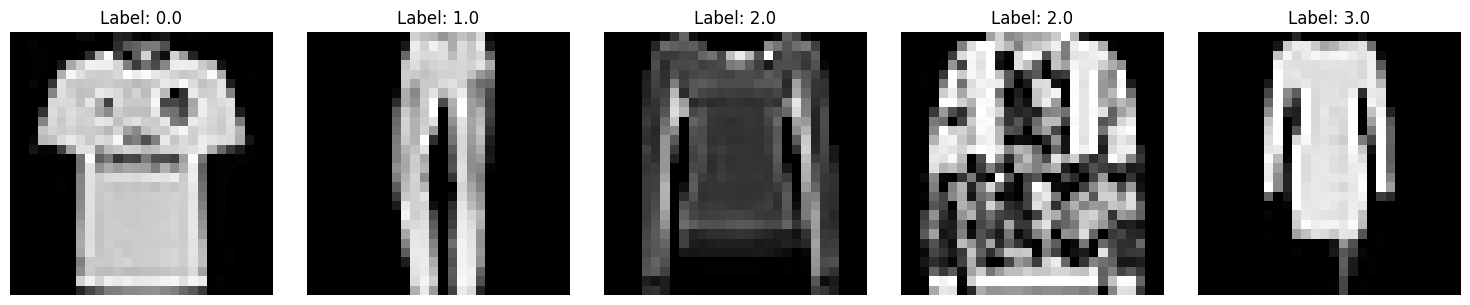

In [9]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots arranged in 1 row and 5 columns.
# Adjust figsize as needed to fit the images well.
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Loop through the first 5 rows of the DataFrame to visualize multiple images.
for i in range(5):
    # Select the current row of the DataFrame.
    image_data = df.iloc[i]

    # The first column is the 'label', so we exclude it to get only pixel data.
    pixel_values = image_data[1:].values

    # Reshape the 784 pixel values into a 28x28 array.
    image = pixel_values.reshape(28, 28)

    # Display the image on the current subplot.
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {image_data['label']}") # Add a title with the image's label
    axes[i].axis('off') # Hide the axes for a cleaner image display

plt.tight_layout() # Adjust layout to prevent titles/labels from overlapping
plt.show()

In [10]:
X = df.iloc[:, 1:].values # Corrected to include all pixel columns
y = df.iloc[:, 0].values

In [11]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [12]:
# scaling the features
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
# create CustomDataset class
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    super().__init__() # Corrected line
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [14]:
# create train_dataset
train_dataset = CustomDataset(X_train, y_train)

In [15]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [16]:
test_dataset = CustomDataset(X_test, y_test)

In [17]:
# create train and test loader
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle = True
)

In [10]:
import torch.nn as nn

class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.3))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

In [13]:
device = 'cuda'
# objective function
def objective(trial):
  import torch.optim as optim # Added import statement here
  #  next hyperparameter
  num_hidden_layers = trial.suggest_int("num_hidden_layeres",1,5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 128, step=8)

  # model initialized
  input_dim = 784
  output_dim = 10

  model =  MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer)
  model.to(device)

  # parms init

  # optimizer
  epochs = 100
  learning_rate = 0.1

  # loss function
  criterion = nn.CrossEntropyLoss()

  # optimizer
  optimizer = optim.SGD(model.parameters(),lr = learning_rate, weight_decay=0.001)

  # training loop
  # Training loop
  # Using the previously defined epochs variable

  # Lists to store loss for plotting
  loss_history = []

  for epoch in range(epochs):
    current_loss = 0.0
    for batch_features, batch_labels in train_loader:
      # Forward pass
      outputs = model(batch_features)

      # Calculate loss
      loss = criterion(outputs, batch_labels)
      current_loss += loss.item()

      # Backward pass and optimize
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {current_loss/len(train_loader):.4f}')
    loss_history.append(current_loss/len(train_loader))

  print('Training finished.')

  # evaluation
  model.eval()
  total = 0
  correct = 0

  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      outputs = model(batch_features)
      _, predicted = torch.max(outputs, 1)
      total = total + batch_labels.shape[0]
      correct = correct + (predicted == batch_labels).sum().item()

  accuracy = correct / total
  return accuracy

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.3 MB/s eta 0:00:00


In [16]:
import optuna

In [17]:
study = optuna.create_study(direction='maximize')

[I 2025-11-15 04:41:12,318] A new study created in memory with name: no-name-c6bf5f2e-e2cd-4e44-bde1-4e5982c09e96


In [19]:
study.optimize(objective, n_trials=10)

[W 2025-11-15 04:41:45,935] Trial 1 failed with parameters: {'num_hidden_layeres': 4, 'neurons_per_layer': 16} because of the following error: NameError("name 'train_loader' is not defined").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-3582917404.py", line 37, in objective
    for batch_features, batch_labels in train_loader:
                                        ^^^^^^^^^^^^
NameError: name 'train_loader' is not defined
[W 2025-11-15 04:41:45,955] Trial 1 failed with value None.


NameError: name 'train_loader' is not defined

# Task
Create an Optuna study to optimize the hyperparameters of the `MyNN` model by running 10 trials, aiming to maximize accuracy. This involves re-running the neural network model and objective function definitions, creating `train_loader` and `test_loader` data loaders, and then executing the optimization process.

## Define Neural Network Model

### Subtask:
Re-run the cell that defines the `MyNN` class (cell `HosiO-Swv7_q`) to ensure the model architecture is correctly loaded into the kernel. This is important as recent changes were made to its definition.


**Reasoning**:
The subtask explicitly asks to re-run the cell `HosiO-Swv7_q` to define the `MyNN` class, which is crucial for the subsequent steps.



In [20]:
import torch.nn as nn

class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.3))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

**Reasoning**:
The subtask explicitly asks to re-run the cell `HosiO-Swv7_q` to define the `MyNN` class, which is crucial for the subsequent steps.



In [21]:
import torch.nn as nn

class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.3))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

## Define Objective Function

### Subtask:
Re-run the cell that defines the `objective` function (cell `DJO1L2fKuaiq`). This function contains the training and evaluation logic for Optuna and has also undergone recent modifications.


**Reasoning**:
The subtask explicitly asks to re-run the cell `DJO1L2fKuaiq` to define the `objective` function, which is crucial for the subsequent steps.



In [22]:
device = 'cuda'
# objective function
def objective(trial):
  import torch.optim as optim # Added import statement here
  #  next hyperparameter
  num_hidden_layers = trial.suggest_int("num_hidden_layeres",1,5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 128, step=8)

  # model initialized
  input_dim = 784
  output_dim = 10

  model =  MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer)
  model.to(device)

  # parms init

  # optimizer
  epochs = 100
  learning_rate = 0.1

  # loss function
  criterion = nn.CrossEntropyLoss()

  # optimizer
  optimizer = optim.SGD(model.parameters(),lr = learning_rate, weight_decay=0.001)

  # training loop
  # Training loop
  # Using the previously defined epochs variable

  # Lists to store loss for plotting
  loss_history = []

  for epoch in range(epochs):
    current_loss = 0.0
    for batch_features, batch_labels in train_loader:
      # Forward pass
      outputs = model(batch_features)

      # Calculate loss
      loss = criterion(outputs, batch_labels)
      current_loss += loss.item()

      # Backward pass and optimize
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {current_loss/len(train_loader):.4f}')
    loss_history.append(current_loss/len(train_loader))

  print('Training finished.')

  # evaluation
  model.eval()
  total = 0
  correct = 0

  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      outputs = model(batch_features)
      _, predicted = torch.max(outputs, 1)
      total = total + batch_labels.shape[0]
      correct = correct + (predicted == batch_labels).sum().item()

  accuracy = correct / total
  return accuracy

**Reasoning**:
The previous execution of `study.optimize` failed because `train_loader` and `test_loader` were not defined in the scope where the `objective` function was called by Optuna. Although they were defined earlier in the notebook, Optuna's execution context might require them to be explicitly available or re-defined within the `objective` function's accessible scope, or simply, they were not re-executed after the kernel restart or some other event. To fix this, the next step is to ensure `train_loader` and `test_loader` are properly initialized.



In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle = True
)

NameError: name 'DataLoader' is not defined

**Reasoning**:
The previous attempt to create `train_loader` and `test_loader` failed because `DataLoader` was not defined. This indicates that the `DataLoader` class from `torch.utils.data` was not imported into the current kernel session. To resolve this, I need to add the import statement for `DataLoader` before instantiating the data loaders.



In [24]:
from torch.utils.data import DataLoader
# create train and test loader
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle = True
)

NameError: name 'train_dataset' is not defined

**Reasoning**:
The previous attempt to create `train_loader` and `test_loader` failed because `train_dataset` was not defined. This indicates that the `CustomDataset` class and the `train_dataset` and `test_dataset` objects were not created or were cleared from the kernel's memory. To resolve this, I need to first ensure the `CustomDataset` class is defined, and then create the `train_dataset` and `test_dataset` objects using the `X_train`, `y_train`, `X_test`, `y_test` arrays which are also assumed to be available from previous preprocessing steps.



In [25]:
import torch
from torch.utils.data import Dataset # Ensure Dataset is imported

# create CustomDataset class
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    super().__init__()
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

**Reasoning**:
The `CustomDataset` class has been defined. Now, I need to create instances of `train_dataset` and `test_dataset` using the `CustomDataset` class and the previously prepared `X_train`, `y_train`, `X_test`, and `y_test` arrays. This is necessary because the previous steps indicated `train_dataset` was not defined.



In [26]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)
print("train_dataset and test_dataset created.")

NameError: name 'X_train' is not defined

**Reasoning**:
The previous attempt to create `train_dataset` and `test_dataset` failed because `X_train` and `y_train` were not defined. This indicates that the data extraction, train-test split, and scaling steps were not executed or their results were cleared. I need to re-run these data preparation steps to ensure `X_train`, `y_train`, `X_test`, and `y_test` are available.



In [27]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

X_train = X_train/255.0
X_test = X_test/255.0

print("Data (X_train, y_train, X_test, y_test) prepared and scaled.")

NameError: name 'df' is not defined